# Showcase — the GERD reservoir filling on the Blue Nile (2020 → 2024)

The Grand Ethiopian Renaissance Dam impounds the Blue Nile; its reservoir was filled in stages from 2020 to 2024. This notebook fetches one dry-season Sentinel-2 composite per year, reads them with `DatasetCollection.read_multiple_files()`, shows the fill in **true colour** with `Dataset.plot(rgb_options=...)`, animates the open water with an **NDWI** stack, and measures the water-surface area each year.

## What this notebook does

1. **Fetch** one dry-season Sentinel-2 composite per year (2020–2024) — true colour `B4,B3,B2` plus `B8` (NIR) — and derive an NDWI raster per year.
2. **True-colour progression** of the five years with `Dataset.plot(rgb_options=...)`.
3. **Animated true colour** — the same composites as a real-colour GIF.
4. **Animate** the open water (NDWI) with `DatasetCollection.plot().save_animation()`.
5. **Measure** the reservoir's water-surface area per year from NDWI.

NDWI = (Green − NIR)/(Green + NIR) > 0 marks open water.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`.

In [1]:
import os, shutil, tempfile, warnings
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from IPython.display import Image, display
from earthlens import EarthLens
from pyramids.dataset import Dataset, DatasetCollection   # pyramids' own IO + plotting

warnings.filterwarnings("ignore")
logger.remove()
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

def grab(collection, aoi, start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start, end]; return its GeoTIFF path or None."""
    el = EarthLens(data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={collection: list(bands)}, lat_lim=[aoi[1], aoi[3]], lon_lim=[aoi[0], aoi[2]],
        path=tempfile.mkdtemp(), scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001 - needs GEE credentials
        print("download skipped:", exc); return None
    return str(p[0]) if p else None

AOI = [34.95, 11.05, 35.25, 11.32]; C = "COPERNICUS/S2_SR_HARMONIZED"
rgb_dir, ndwi_dir = tempfile.mkdtemp(), tempfile.mkdtemp()
labels = []
for y in range(2020, 2025):
    p = grab(C, AOI, f"{y}-11-01", f"{y}-12-28", ["B4", "B3", "B2", "B8"], scale=30)
    if not p:
        continue
    shutil.copy(p, os.path.join(rgb_dir, f"gerd_{y}.tif"))                  # true colour (+NIR)
    a = np.asarray(Dataset.read_file(p).read_array(), dtype="float32")
    ndwi = (a[1] - a[3]) / (a[1] + a[3] + 1e-6)                              # (Green - NIR)/(Green + NIR)
    src = Dataset.read_file(p)
    (Dataset.create_from_array(arr=ndwi[None, :, :], geo=src.geotransform, epsg=src.epsg)
            .to_file(os.path.join(ndwi_dir, f"ndwi_{y}.tif")))              # persist derived NDWI
    labels.append(str(y))
dc_rgb = DatasetCollection.read_multiple_files(rgb_dir, date=False) if labels else None
dc_ndwi = DatasetCollection.read_multiple_files(ndwi_dir, date=False) if labels else None
print(f"{len(labels)} yearly composites:", labels)

5 yearly composites: ['2020', '2021', '2022', '2023', '2024']


## True-colour progression — `Dataset.plot(rgb_options=...)`

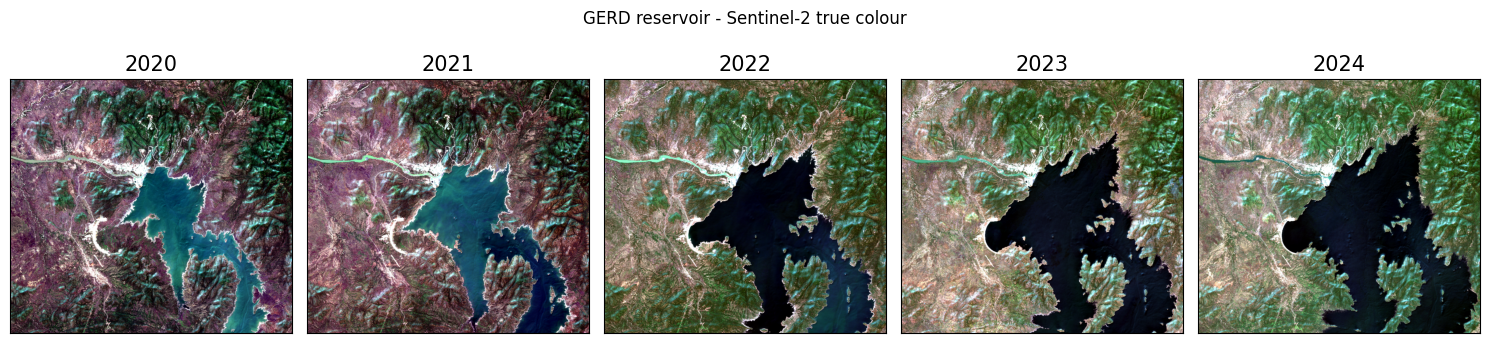

In [2]:
# Each year as a real-colour composite; the reservoir grows behind the dam.
if dc_rgb:
    n = dc_rgb.time_length
    fig, ax = plt.subplots(1, n, figsize=(3.0 * n, 3.4))
    for i, y in enumerate(labels):
        dc_rgb.iloc(i).plot(rgb_options={"rgb": [0, 1, 2], "percentile": 2}, ax=ax[i], title=y)
        ax[i].set_xticks([]); ax[i].set_yticks([])
    fig.suptitle("GERD reservoir - Sentinel-2 true colour", y=1.03)
    plt.tight_layout(); plt.show()
else:
    print("no scenes - set GEE_SERVICE_ACCOUNT / GEE_SERVICE_KEY and rerun")

## Animated true colour

The five dry-season composites as a real-colour animation — the reservoir visibly grows behind the dam. `DatasetCollection.plot()` animates a single band, so each RGB frame is prepared with cleopatra's `ArrayGlyph.prepare_array` and stepped into a GIF.

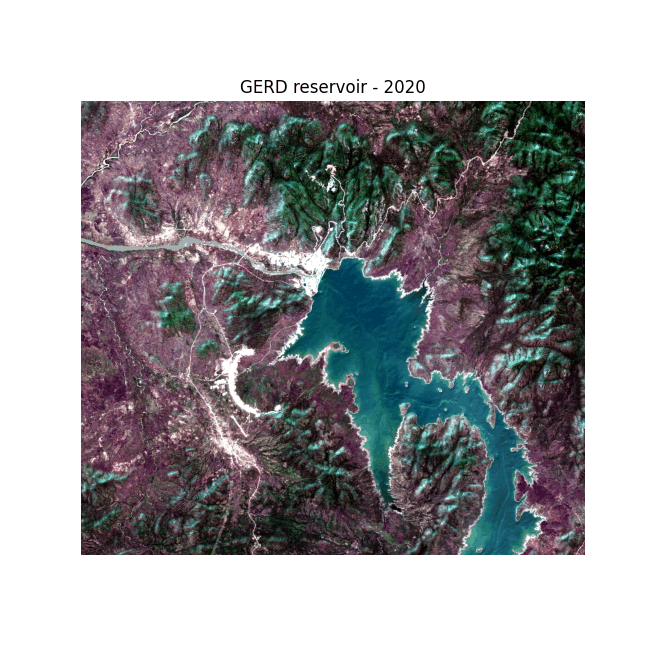

In [3]:
# DatasetCollection.plot animates ONE band, so for true colour we prepare each RGB
# frame with cleopatra's ArrayGlyph.prepare_array (the exact stretch Dataset.plot's
# rgb path uses) and step the frames with matplotlib into a GIF.
from cleopatra.array_glyph import ArrayGlyph
from matplotlib.animation import FuncAnimation, PillowWriter

if dc_rgb:
    helper = ArrayGlyph(np.zeros((1, 1)))   # bare glyph: only its prepare_array is used
    frames = [helper.prepare_array(np.asarray(dc_rgb.iloc(i).read_array(), dtype="float32")[:3],
                                   rgb=[0, 1, 2], percentile=2)
              for i in range(dc_rgb.time_length)]
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    im = ax.imshow(frames[0]); ax.axis("off")
    def _step(i):
        im.set_data(frames[i]); ax.set_title(f"GERD reservoir - {labels[i]}")
        return [im]
    anim = FuncAnimation(fig, _step, frames=len(frames), interval=800)
    gif = os.path.join(tempfile.mkdtemp(), "true_colour.gif")
    anim.save(gif, writer=PillowWriter(fps=1.2))
    plt.close(fig)
    display(Image(filename=gif))
else:
    print("no scenes to animate")

## Animated reservoir filling (NDWI) — `DatasetCollection.plot().save_animation()`

NDWI is a single-band water index (high over open water), so the collection animates it directly — the blue pool spreads year on year as the reservoir fills.

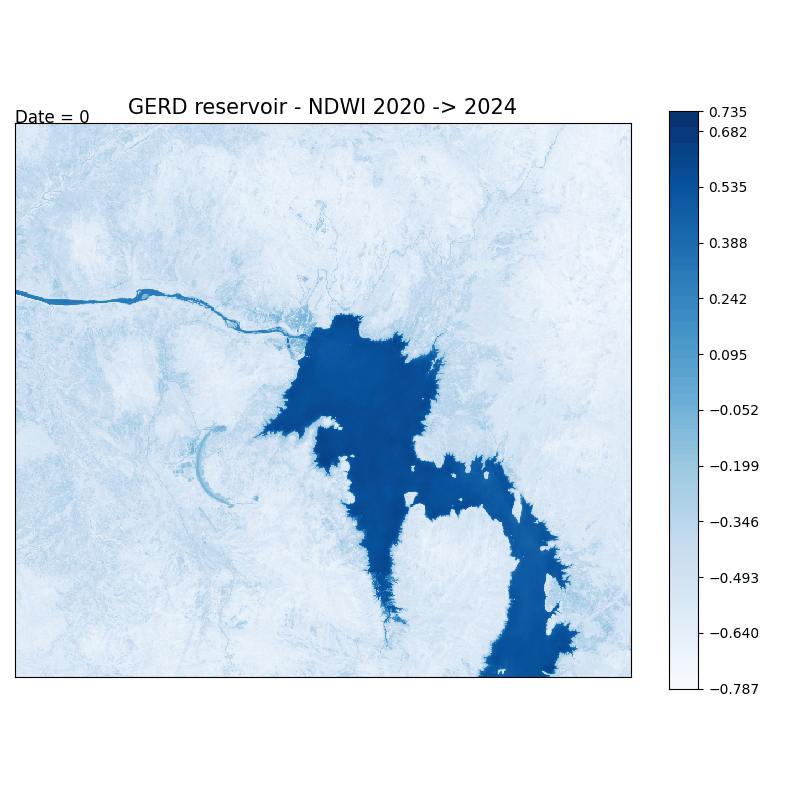

In [4]:
if dc_ndwi:
    gif = os.path.join(tempfile.mkdtemp(), "ndwi.gif")
    dc_ndwi.plot(band=0, cmap="Blues", title="GERD reservoir - NDWI 2020 -> 2024").save_animation(gif, fps=1)
    plt.close("all")
    display(Image(filename=gif))
else:
    print("no scenes - set GEE credentials and rerun")

## Reservoir surface area each year (NDWI)

NDWI = (Green − NIR)/(Green + NIR) > 0 marks open water; counting those pixels gives the surface area, which climbs year on year.

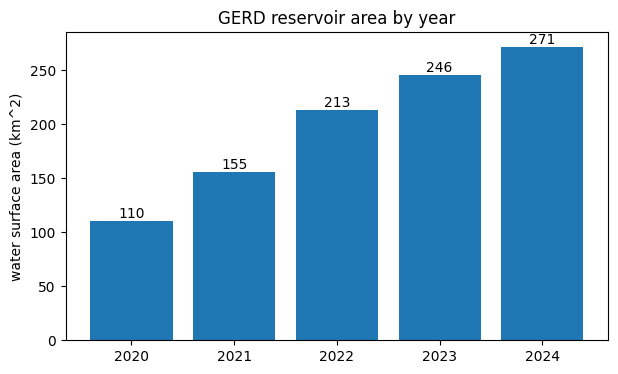

reservoir area (km^2): {'2020': 110, '2021': 155, '2022': 213, '2023': 246, '2024': 271}


In [5]:
# NDWI water area per year (count NDWI>0 pixels read straight from the collection).
if dc_rgb:
    px_km2 = (30 * 30) / 1e6; areas = []
    for i in range(dc_rgb.time_length):
        a = np.asarray(dc_rgb.iloc(i).read_array(), dtype="float32")
        ndwi = (a[1] - a[3]) / (a[1] + a[3] + 1e-6)
        areas.append(float(np.sum(ndwi > 0) * px_km2))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, areas, color="tab:blue")
    for i, v in enumerate(areas):
        ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
    ax.set(ylabel="water surface area (km^2)", title="GERD reservoir area by year"); plt.show()
    print("reservoir area (km^2):", {l: round(v) for l, v in zip(labels, areas)})

## Annual fill rate

Differencing the yearly surface areas gives how much new water the reservoir gained each year — the pace of the staged filling.

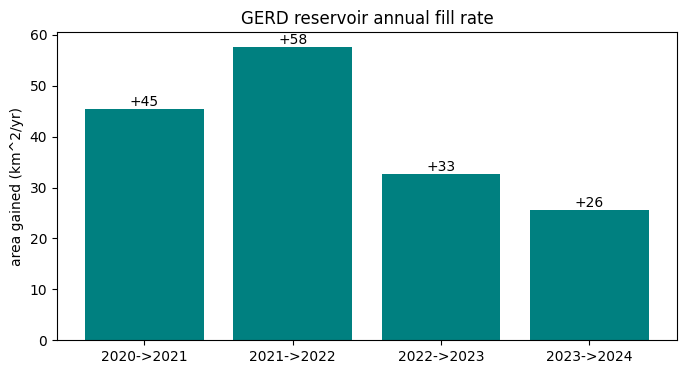

annual gain (km^2): {'2020->2021': 45, '2021->2022': 58, '2022->2023': 33, '2023->2024': 26}


In [6]:
# Year-over-year growth from the NDWI areas computed above.
if dc_rgb and len(areas) > 1:
    rates = [areas[i] - areas[i-1] for i in range(1, len(areas))]
    yl = [f"{labels[i-1]}->{labels[i]}" for i in range(1, len(labels))]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(yl, rates, color="teal")
    for i, v in enumerate(rates):
        ax.text(i, v, f"+{v:.0f}", ha="center", va="bottom")
    ax.set(ylabel="area gained (km^2/yr)", title="GERD reservoir annual fill rate")
    plt.show()
    print("annual gain (km^2):", dict(zip(yl, [round(r) for r in rates])))
else:
    print("no areas to difference")

## Recap

The yearly series is read from one folder with `DatasetCollection.read_multiple_files()`; the progression renders in true colour with `Dataset.plot(rgb_options=...)` and animates as a real-colour GIF, the NDWI stack animates with `DatasetCollection.plot().save_animation()`, and counting NDWI>0 pixels turns it into a surface-area-per-year curve.

## Try it yourself

- Point `AOI` at another reservoir, or animate a different index.
- See the [GEE backend reference](../../reference/gee/introduction.md).